### ** Мета проєкту**

Метою цього аналізу є визначення найбільш надійних банків України для збереження коштів.

Під "надійністю" в рамках цього дослідження розглядаються:
- достатній рівень власного капіталу (стійкість)
- здатність покривати зобов’язання ліквідними коштами (ліквідність)
- стабільність та ефективність діяльності (прибутковість)

Для аналізу використано квартальні дані фінансової звітності банків за період 2018–2026 років.

In [1]:
import pandas as pd
import requests

1. ## Завантаження та підготовка довідника банків

На першому етапі було завантажено довідник банків з API НБУ.


In [2]:
url = 'https://bank.gov.ua/NBU_BankInfo/get_data_branch?typ=0&json'
data = requests.get(url).json()
banks = pd.DataFrame(data)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
banks.head()


,GLMFO,N_GOL,NAME_E,KOD_EDRPOU,SHORTNAME,FULLNAME,NKB,TYP,KU,N_OBL,DEPCODE,P_IND,TNP,NP,ADRESS,KODT,TELEFON,KSTAN,N_STAN,D_STAN,D_OPEN,D_CLOSE,STAN_GOL,NSTAN_GOL,MFO,IDNBU,UNIQ_NUM,ID_NBU_PARENT
0,300012,"ПАТ ""Промінвестбанк""","Public stock company ""Joint-Stock Commercial I...",00039002,"ПАТ ""Промінвестбанк""","Публічне акціонерне товариство ""Акціонерний ко...",003,0,26,м.Київ,None,01001,м.,Київ,"вул. Малопідвальна, 8",None,None,4,Ліквідація,25.02.2022,26.08.1992,None,4,Ліквідація,300012,300012,None,None
1,300119,"АТ ""БАНК АЛЬЯНС""","JOINT STOCK COMPANY ""BANK ALLIANCE""",14360506,"АТ ""БАНК АЛЬЯНС""","АКЦІОНЕРНЕ ТОВАРИСТВО ""БАНК АЛЬЯНС""",029,0,26,м.Київ,None,04053,м.,Київ,"вулиця Січових Стрільців, будинок 50",None,0 (800) 600-202,1,Нормальний,None,10.03.1992,None,1,Нормальний,300119,300119,None,None
2,300120,"ПАТ ""БАНК ПЕТРОКОММЕРЦ-УКРАЇНА""","PUBLIC JOINT-STOCK COMPANY ""PETROCOMMERCE-UKRA...",22906155,"ПАТ ""БАНК ПЕТРОКОММЕРЦ-УКРАЇНА""","ПУБЛІЧНЕ АКЦІОНЕРНЕ ТОВАРИСТВО ""БАНК ПЕТРОКОММ...",283,0,26,м.Київ,28326804026723000000,01601,м.,Київ,"вулиця Велика Житомирська, 20",None,None,4,Ліквідація,21.04.2016,26.09.1996,None,4,Ліквідація,300120,300120,None,None
3,300131,"АТ ""БАНК ""ФІНАНСИ ТА КРЕДИТ""","PUBLIC JOINT STOCK COMPANY ""BANK ""FINANCE AND ...",09807856,"АТ ""БАНК ""ФІНАНСИ ТА КРЕДИТ""","ПУБЛІЧНЕ АКЦІОНЕРНЕ ТОВАРИСТВО ""БАНК ""ФІНАНСИ ...",017,0,26,м.Київ,01726804026708000000,04050,м.,Київ,вул. Артема‚ 60,None,None,4,Ліквідація,17.12.2015,30.10.1991,None,4,Ліквідація,300131,300131,None,None
4,300142,"ПАТ ""УКРІНБАНК""","PUBLIC JOINT-STOCK COMPANY ""UKRAINIAN INNOVATI...",05839888,"ПАТ ""УКРІНБАНК""","ПУБЛІЧНЕ АКЦІОНЕРНЕ ТОВАРИСТВО ""УКРАЇНСЬКИЙ ІН...",018,0,26,м.Київ,01826804026709000000,04053,м.,Київ,"вул. Смирнова-Ласточкіна, буд.10-А",None,None,4,Ліквідація,22.03.2016,02.10.1991,None,4,Ліквідація,300142,300142,None,None


In [3]:

banks['N_STAN'].unique()

array(['Ліквідація', 'Нормальний', 'Неплатоспроможний'], dtype=object)

In [4]:
banks[['KSTAN', 'N_STAN']].drop_duplicates()

,KSTAN,N_STAN
0,4,Ліквідація
1,1,Нормальний
12,9,Неплатоспроможний


In [5]:
banks['N_STAN'].value_counts()

,count
N_STAN,
Нормальний,58
Ліквідація,54
Неплатоспроможний,1


In [6]:
banks.columns

Index(['GLMFO', 'N_GOL', 'NAME_E', 'KOD_EDRPOU', 'SHORTNAME', 'FULLNAME',
       'NKB', 'TYP', 'KU', 'N_OBL', 'DEPCODE', 'P_IND', 'TNP', 'NP', 'ADRESS',
       'KODT', 'TELEFON', 'KSTAN', 'N_STAN', 'D_STAN', 'D_OPEN', 'D_CLOSE',
       'STAN_GOL', 'NSTAN_GOL', 'MFO', 'IDNBU', 'UNIQ_NUM', 'ID_NBU_PARENT'],
      dtype='object')

2. ## Вибір необхідних колонок

На цьому етапі було залишено лише ті змінні, які необхідні для подальшого аналізу.

Зокрема, з довідника банків були виключені технічні та довідкові поля (адреса, контакти, службові коди тощо), які не впливають на оцінку фінансової надійності.

У результаті залишено основні характеристики банків:
- назва
- код ЄДРПОУ
- МФО
- статус банку
- дата відкриття

In [7]:
banks = banks[['KOD_EDRPOU', 'SHORTNAME', 'N_STAN', 'D_STAN', 'D_OPEN', 'MFO']]
banks

,KOD_EDRPOU,SHORTNAME,N_STAN,D_STAN,D_OPEN,MFO
0,00039002,"ПАТ ""Промінвестбанк""",Ліквідація,25.02.2022,26.08.1992,300012
1,14360506,"АТ ""БАНК АЛЬЯНС""",Нормальний,None,10.03.1992,300119
2,22906155,"ПАТ ""БАНК ПЕТРОКОММЕРЦ-УКРАЇНА""",Ліквідація,21.04.2016,26.09.1996,300120
3,09807856,"АТ ""БАНК ""ФІНАНСИ ТА КРЕДИТ""",Ліквідація,17.12.2015,30.10.1991,300131
4,05839888,"ПАТ ""УКРІНБАНК""",Ліквідація,22.03.2016,02.10.1991,300142
...,...,...,...,...,...,...
108,37716841,"АТ ""БАНК СІЧ""",Ліквідація,10.10.2022,24.05.2011,380816
109,14360920,"АТ ""ПРАВЕКС БАНК""",Нормальний,None,29.12.1992,380838
110,26520688,"АТ ""УБРР""",Нормальний,None,19.03.2004,380883
111,38619024,"ПАТ ""БАНК МИХАЙЛІВСЬКИЙ""",Ліквідація,12.07.2016,14.06.2013,380935


3. ## Фільтрація банків за статусом

На цьому етапі з вибірки було виключено банки, які:
- перебувають у стані ліквідації
- визнані неплатоспроможними

Для подальшого аналізу залишено лише банки зі статусом "Нормальний", тобто діючі установи.

Це дозволяє оцінювати надійність саме тих банків, які потенційно можуть використовуватись для розміщення заощаджень.

In [8]:
active_banks = banks[banks['N_STAN']=='Нормальний'].copy()
active_banks['D_OPEN'] = pd.to_datetime(active_banks['D_OPEN'], format='%d.%m.%Y', errors='coerce')
active_banks = active_banks.sort_values(by='D_OPEN').reset_index().drop(columns='index')
active_banks.head()

,KOD_EDRPOU,SHORTNAME,N_STAN,D_STAN,D_OPEN,MFO
0,09306278,"АТ ""ОКСІ БАНК""",Нормальний,None,1991-10-14,325990
1,09801546,"АТ АКБ ""Львів""",Нормальний,None,1991-10-14,325268
2,09807595,"АТ ""Полтава-банк""",Нормальний,None,1991-10-16,331489
3,13857564,"АКБ ""ІНДУСТРІАЛБАНК""",Нормальний,None,1991-10-16,313849
4,09806443,"АТ ""ТАСКОМБАНК""",Нормальний,10.12.2018,1991-10-21,339500


## 4. Завантаження фінансових даних

На цьому етапі було завантажено квартальні дані фінансової звітності банків з API НБУ.

Для аналізу обрано період з 2018 року. Це пов’язано з тим, що починаючи зі звітної дати 01.10.2017 НБУ публікує згруповані балансові залишки банків за новою методологією.

Дані за попередні періоди мають іншу структуру та не є повністю зіставними, тому були виключені з аналізу.

Отримані дані для кожної дати були об’єднані в єдину таблицю для подальшої обробки.

In [9]:
all_data = []
dates = pd.date_range(start='2018-01-01', end="2026-05-01", freq='QS')
for date in dates:
    date_str = date.strftime('%Y%m%d')
    url = f'https://bank.gov.ua/NBUStatService/v1/statdirectory/banksfinrep?date={date_str}&period=q&json'

    try:
        response = requests.get(url)
        response.raise_for_status()  # перевіряє, чи запит виконано успішно; у разі помилки (не 200) зупиняє виконання

        data = response.json()
        df = pd.DataFrame(data)
        df['report_date'] = date

        all_data.append(df)

    except Exception as e:
        print(f"Помилка для дати {date_str}: {e}")

In [10]:
bank_indicators = pd.concat(all_data, ignore_index=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
bank_indicators.head()

,dt,txt,txten,id_api,leveli,parent,freq,nkb,mfo,fullname,gr_bank,r034,tzep,value,report_date
0,20180101,Доходи і витрати - Заробітна плата персоналу,Income and Expences - Payroll costs,BS1_Payroll,3.0,BS1_AdminOperCosts,Q,2,322313,"АТ ""Укрексімбанк""",A,1,T070_7,631.7840,2018-01-01
1,20180101,Доходи і витрати - Заробітна плата персоналу,Income and Expences - Payroll costs,BS1_Payroll,3.0,BS1_AdminOperCosts,Q,3,300012,"ПАТ ""Промінвестбанк""",B,1,T070_7,262.6229,2018-01-01
2,20180101,Доходи і витрати - Заробітна плата персоналу,Income and Expences - Payroll costs,BS1_Payroll,3.0,BS1_AdminOperCosts,Q,5,300023,"АТ ""УКРСОЦБАНК""",B,1,T070_7,509.8521,2018-01-01
3,20180101,Доходи і витрати - Заробітна плата персоналу,Income and Expences - Payroll costs,BS1_Payroll,3.0,BS1_AdminOperCosts,Q,6,300465,"АТ ""Ощадбанк""",A,1,T070_7,2896.7124,2018-01-01
4,20180101,Доходи і витрати - Заробітна плата персоналу,Income and Expences - Payroll costs,BS1_Payroll,3.0,BS1_AdminOperCosts,Q,29,300119,"АТ ""БАНК АЛЬЯНС""",E,1,T070_7,29.0990,2018-01-01


In [11]:
bank_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236573 entries, 0 to 236572
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   dt           236573 non-null  object        
 1   txt          236573 non-null  object        
 2   txten        236573 non-null  object        
 3   id_api       236573 non-null  object        
 4   leveli       236573 non-null  float64       
 5   parent       236573 non-null  object        
 6   freq         236573 non-null  object        
 7   nkb          236573 non-null  object        
 8   mfo          236573 non-null  object        
 9   fullname     236573 non-null  object        
 10  gr_bank      236573 non-null  object        
 11  r034         236573 non-null  object        
 12  tzep         236573 non-null  object        
 13  value        236573 non-null  float64       
 14  report_date  236573 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), 

5. З таблиці фінансової звітності було залишено лише колонки, необхідні для аналізу показників у динаміці: банк, назва показника, код показника, значення та звітна дата.

In [12]:
cols = ['mfo', 'txt', 'id_api', 'value', 'dt']
bank_indicators_clean = bank_indicators[cols].copy()
bank_indicators_clean['dt'] = pd.to_datetime(bank_indicators_clean['dt'], format='%Y%m%d', errors='coerce')
bank_indicators_clean

,mfo,txt,id_api,value,dt
0,322313,Доходи і витрати - Заробітна плата персоналу,BS1_Payroll,631.7840,2018-01-01
1,300012,Доходи і витрати - Заробітна плата персоналу,BS1_Payroll,262.6229,2018-01-01
2,300023,Доходи і витрати - Заробітна плата персоналу,BS1_Payroll,509.8521,2018-01-01
3,300465,Доходи і витрати - Заробітна плата персоналу,BS1_Payroll,2896.7124,2018-01-01
4,300119,Доходи і витрати - Заробітна плата персоналу,BS1_Payroll,29.0990,2018-01-01
...,...,...,...,...,...
236568,377090,Доходи і витрати - Чисте (збільшення) зменшенн...,BS1_NetIncrProvImpReceiv,3.4303,2026-01-01
236569,380731,Доходи і витрати - Чисте (збільшення) зменшенн...,BS1_NetIncrProvImpReceiv,0.9704,2026-01-01
236570,380797,Доходи і витрати - Чисте (збільшення) зменшенн...,BS1_NetIncrProvImpReceiv,0.0000,2026-01-01
236571,380946,Доходи і витрати - Чисте (збільшення) зменшенн...,BS1_NetIncrProvImpReceiv,0.0000,2026-01-01


In [13]:
count = bank_indicators_clean.value_counts('txt').reset_index()
count

,txt,count
0,Активи - Усього активів,4636
1,"Активи - Чисті активи, усього",4636
2,Зобов'язання - Усього зобов’язань,4631
3,Зобов'язання - Кошти клієнтів,4626
4,"Активи - Provisions, total",4617
...,...,...
91,Зобов'язання - Кошти отримані від НБУ,670
92,Капітал - Інший додатковий капітал,640
93,Активи - Інвестиції в асоційовані та дочірні к...,438
94,"Зобов'язання - Боргові цінні папери, емітовані...",297


In [14]:
metrics = bank_indicators_clean[['txt', 'id_api']].drop_duplicates()
metrics

,txt,id_api
0,Доходи і витрати - Заробітна плата персоналу,BS1_Payroll
84,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash
252,Активи - Інші фінансові активи,BS1_AssetsOtherFin
420,Капітал - Інший додатковий капітал,BS1_OtherCapital
504,"Активи - Фінансові активи, що обліковуються за...",BS1_FinAssetsFairVal
...,...,...
11760,Доходи і витрати - Результат від операцій з ку...,BS1_ResPurSale
11844,Доходи і витрати - Інші доходи,BS1_OtherIncome
11928,Активи - Резерви під знецінення цінних паперів...,BS1_AssetsProvSecurFVOCI
12096,Доходи і витрати - Чисте (збільшення) зменшенн...,BS1_NetIncrProvImpReceiv


6. Для подальшого аналізу було відібрано ключові фінансові показники, що характеризують активи, зобов’язання, капітал, ліквідність та прибутковість банків.

In [15]:
important_metrics = [
    'BS1_AssetsTotal',
    'BS1_AssetsLoansClients',
    'BS1_AssetsCash',
    'BS1_LiabCust',
    'BS1_CapitalTotal',
    'BS1_ProfitLossAfterTax'
]

bank_indicators_clean = bank_indicators_clean[bank_indicators_clean['id_api'].isin(important_metrics)]
bank_indicators_clean

,mfo,txt,id_api,value,dt
84,322313,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,6133.7452,2018-01-01
85,300012,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,465.6789,2018-01-01
86,300023,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,1260.6878,2018-01-01
87,300465,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,11032.3047,2018-01-01
88,300119,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,33.4073,2018-01-01
...,...,...,...,...,...
234192,380946,Активи - Усього активів,BS1_AssetsTotal,258.7003,2026-01-01
234193,380946,Активи - Усього активів,BS1_AssetsTotal,1183.7482,2026-01-01
234194,339050,Активи - Усього активів,BS1_AssetsTotal,445.1004,2026-01-01
234195,339050,Активи - Усього активів,BS1_AssetsTotal,2476.7676,2026-01-01


In [16]:
bank_indicators_clean['id_api'].unique()

array(['BS1_AssetsCash', 'BS1_LiabCust', 'BS1_ProfitLossAfterTax',
       'BS1_AssetsLoansClients', 'BS1_CapitalTotal', 'BS1_AssetsTotal'],
      dtype=object)

In [17]:
bank_indicators_clean['txt'].unique()

array(['Активи - Грошові кошти та їх еквіваленти',
       "Зобов'язання - Кошти клієнтів",
       'Доходи і витрати - Прибуток/(збиток) після оподаткування',
       'Активи - Кредити та заборгованість клієнтів',
       'Капітал - Усього власного капіталу', 'Активи - Усього активів'],
      dtype=object)

In [18]:
bank_indicators_clean.groupby('id_api')['value'].count()

,value
id_api,
BS1_AssetsCash,4549
BS1_AssetsLoansClients,4357
BS1_AssetsTotal,4636
BS1_CapitalTotal,2320
BS1_LiabCust,4626
BS1_ProfitLossAfterTax,2320


7. Фінансові дані  відфільтровано, залишивши лише записи для активних банків зі статусом "Нормальний".

In [19]:
active_mfo = active_banks['MFO'].astype(str).unique()
df_filtered = bank_indicators_clean[bank_indicators_clean['mfo'].isin(active_mfo)]
df_filtered


,mfo,txt,id_api,value,dt
84,322313,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,6133.7452,2018-01-01
87,300465,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,11032.3047,2018-01-01
88,300119,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,33.4073,2018-01-01
89,300335,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,7391.1515,2018-01-01
91,320940,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,20.4197,2018-01-01
...,...,...,...,...,...
234192,380946,Активи - Усього активів,BS1_AssetsTotal,258.7003,2026-01-01
234193,380946,Активи - Усього активів,BS1_AssetsTotal,1183.7482,2026-01-01
234194,339050,Активи - Усього активів,BS1_AssetsTotal,445.1004,2026-01-01
234195,339050,Активи - Усього активів,BS1_AssetsTotal,2476.7676,2026-01-01


8. Далі аналізуємо показники банків за останню звітну дату, щоб визначити лідерів.

In [20]:
latest_date = bank_indicators_clean['dt'].max()
df_latest = bank_indicators_clean[bank_indicators_clean['dt'] == latest_date]
df_latest
pivot_df = df_latest.pivot_table(
    index='mfo',
    columns='id_api',
    values='value'
)
pivot_df

id_api,BS1_AssetsCash,BS1_AssetsLoansClients,BS1_AssetsTotal,BS1_CapitalTotal,BS1_LiabCust,BS1_ProfitLossAfterTax
mfo,,,,,,
300119,424.48070,2205.49745,10083.13400,1109.9535,6761.13530,6.7401
300335,20905.82030,41365.92330,131630.12805,39182.1843,100316.90515,10735.9748
300346,5358.45200,26055.36515,77910.78770,14670.2616,59033.79755,3670.5006
300465,24706.75640,64098.26240,268535.34440,47255.4604,221433.13300,16026.6331
300506,19.70035,0.46280,107.53890,110.8310,42.20455,-63.1851
300528,4079.65455,22758.33640,70858.82670,25985.1875,53784.14315,5451.7047
300539,3036.04320,3206.78965,14387.64565,6586.7012,10920.94575,781.7383
300584,5154.98320,4879.94950,48816.31330,17354.9165,39492.38640,4459.5192
300614,5947.39675,17477.59750,63512.50605,18291.2901,51023.48255,5191.6153


In [21]:
pivot_df.sort_values('BS1_AssetsCash', ascending=False).head(10)

id_api,BS1_AssetsCash,BS1_AssetsLoansClients,BS1_AssetsTotal,BS1_CapitalTotal,BS1_LiabCust,BS1_ProfitLossAfterTax
mfo,,,,,,
305299,52152.09795,80422.33215,470543.21375,100283.2203,359513.19845,29082.5079
300465,24706.75640,64098.26240,268535.34440,47255.4604,221433.13300,16026.6331
300335,20905.82030,41365.92330,131630.12805,39182.1843,100316.90515,10735.9748
322001,12989.42705,33590.31420,110219.45365,25637.7799,88182.18075,10375.9635
320478,8556.42565,45723.92400,115793.86325,20418.9507,87008.59490,4868.1668
351005,7992.55625,11716.78045,94449.31595,27172.0466,77463.88275,5802.3215
334851,7598.40380,49072.79455,119935.47875,31570.1359,95288.06280,8051.6889
300614,5947.39675,17477.59750,63512.50605,18291.2901,51023.48255,5191.6153
300346,5358.45200,26055.36515,77910.78770,14670.2616,59033.79755,3670.5006


9. Ранжуємо банки за ключовими фінансовими показниками (активи, капітал, ліквідність, зобов’язання, прибутковість) для визначення найбільш надійних установ.

In [22]:
ranked = pivot_df.copy()

# ранжування (більше = краще)
ranked['r_assets'] = ranked['BS1_AssetsTotal'].rank(ascending=False)             # Активи - Усього активів
ranked['r_capital'] = ranked['BS1_CapitalTotal'].rank(ascending=False)           # Капітал - Усього власного капіталу
ranked['r_cash'] = ranked['BS1_AssetsCash'].rank(ascending=False)                # Активи - Грошові кошти та їх еквіваленти
ranked['r_liab'] = ranked['BS1_LiabCust'].rank(ascending=False)                  # Зобов'язання - Кошти клієнтів
ranked['r_profit'] = ranked['BS1_ProfitLossAfterTax'].rank(ascending=False)      # Доходи і витрати - Прибуток/(збиток) після оподаткування

# сумарний бал (чим менший бал, тим краще становище)
ranked['score'] = (ranked['r_assets'] + ranked['r_capital'] + ranked['r_cash'] + ranked['r_liab'] + ranked['r_profit'])

ranked['capital_ratio'] = round(ranked['BS1_CapitalTotal'] / ranked['BS1_AssetsTotal'], 2)  #скільки власного капіталу в кожній гривні активів
ranked['cash_ratio'] = round(ranked['BS1_AssetsCash'] / ranked['BS1_LiabCust'], 2)          #чи вистачить живих грошей покрити зобов’язання
ranked['roa'] = round(ranked['BS1_ProfitLossAfterTax'] / ranked['BS1_AssetsTotal'], 2)              # ROA — рентабельність активів скільки прибутку на 1 грн активів
ranked['roe'] = round(ranked['BS1_ProfitLossAfterTax'] / ranked['BS1_CapitalTotal'], 2)              #  ROE — рентабельність капіталу наскільки ефективно банк використовує власний капітал

top_banks = ranked.sort_values('score').head(10)
top_banks

id_api,BS1_AssetsCash,BS1_AssetsLoansClients,BS1_AssetsTotal,BS1_CapitalTotal,BS1_LiabCust,BS1_ProfitLossAfterTax,r_assets,r_capital,r_cash,r_liab,r_profit,score,capital_ratio,cash_ratio,roa,roe
mfo,,,,,,,,,,,,,,,,
305299,52152.09795,80422.33215,470543.21375,100283.2203,359513.19845,29082.5079,1.0,1.0,1.0,1.0,1.0,5.0,0.21,0.15,0.06,0.29
300465,24706.75640,64098.26240,268535.34440,47255.4604,221433.13300,16026.6331,2.0,2.0,2.0,2.0,2.0,10.0,0.18,0.11,0.06,0.34
300335,20905.82030,41365.92330,131630.12805,39182.1843,100316.90515,10735.9748,4.0,3.0,3.0,4.0,3.0,17.0,0.30,0.21,0.08,0.27
334851,7598.40380,49072.79455,119935.47875,31570.1359,95288.06280,8051.6889,5.0,4.0,7.0,5.0,6.0,27.0,0.26,0.08,0.07,0.26
322001,12989.42705,33590.31420,110219.45365,25637.7799,88182.18075,10375.9635,7.0,7.0,4.0,6.0,4.0,28.0,0.23,0.15,0.09,0.40
322313,3723.08010,43119.60720,162764.10070,19526.2505,130086.02295,8886.5628,3.0,9.0,12.0,3.0,5.0,32.0,0.12,0.03,0.05,0.46
351005,7992.55625,11716.78045,94449.31595,27172.0466,77463.88275,5802.3215,8.0,5.0,6.0,8.0,7.0,34.0,0.29,0.10,0.06,0.21
320478,8556.42565,45723.92400,115793.86325,20418.9507,87008.59490,4868.1668,6.0,8.0,5.0,7.0,10.0,36.0,0.18,0.10,0.04,0.24
300528,4079.65455,22758.33640,70858.82670,25985.1875,53784.14315,5451.7047,10.0,6.0,11.0,10.0,8.0,45.0,0.37,0.08,0.08,0.21


10. Фільтруємо дані за 2018–2026 роки, залишаючи лише банки з топ-10 за підсумками ранжування.

In [23]:
df_top = df_filtered[df_filtered['mfo'].isin(top_banks.index)].copy()
df_top

,mfo,txt,id_api,value,dt
84,322313,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,6133.7452,2018-01-01
87,300465,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,11032.3047,2018-01-01
89,300335,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,7391.1515,2018-01-01
92,305299,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,15325.1705,2018-01-01
105,334851,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,2128.3335,2018-01-01
...,...,...,...,...,...
234149,300528,Активи - Усього активів,BS1_AssetsTotal,103555.1412,2026-01-01
234158,300614,Активи - Усього активів,BS1_AssetsTotal,40224.6132,2026-01-01
234159,300614,Активи - Усього активів,BS1_AssetsTotal,86800.3989,2026-01-01
234172,320478,Активи - Усього активів,BS1_AssetsTotal,67255.6583,2026-01-01


11. Додаємо до таблиці назву банку

In [24]:
df_top['mfo'] = df_top['mfo'].astype(str)
active_banks = active_banks.copy()
active_banks['MFO'] = active_banks['MFO'].astype(str)
df_top = df_top.merge(active_banks[['MFO', 'SHORTNAME']], left_on='mfo', right_on='MFO', how='left').copy()
df_top.head()

,mfo,txt,id_api,value,dt,MFO,SHORTNAME
0,322313,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,6133.7452,2018-01-01,322313,"АТ ""Укрексімбанк"""
1,300465,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,11032.3047,2018-01-01,300465,"АТ ""Ощадбанк"""
2,300335,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,7391.1515,2018-01-01,300335,"АТ ""Райффайзен Банк"""
3,305299,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,15325.1705,2018-01-01,305299,"АТ КБ ""ПриватБанк"""
4,334851,Активи - Грошові кошти та їх еквіваленти,BS1_AssetsCash,2128.3335,2018-01-01,334851,"АТ ""ПУМБ"""


12. Готуємо зведені таблиці для візуалізації даних для абсолютних показників

In [25]:
pivot_assets = df_top[df_top['id_api'] == 'BS1_AssetsTotal'].pivot_table(index='dt', columns='SHORTNAME', values='value', aggfunc='max')
pivot_capital = df_top[df_top['id_api'] == 'BS1_CapitalTotal'].pivot_table(index='dt', columns='SHORTNAME', values='value', aggfunc='max')
pivot_profit = df_top[df_top['id_api'] == 'BS1_ProfitLossAfterTax'].pivot_table(index='dt', columns='SHORTNAME', values='value', aggfunc='max')
pivot_liab = df_top[df_top['id_api'] == 'BS1_LiabCust'].pivot_table(index='dt', columns='SHORTNAME', values='value', aggfunc='max')


13. Візуалізуємо абсолютні фінансові показники банків у часі

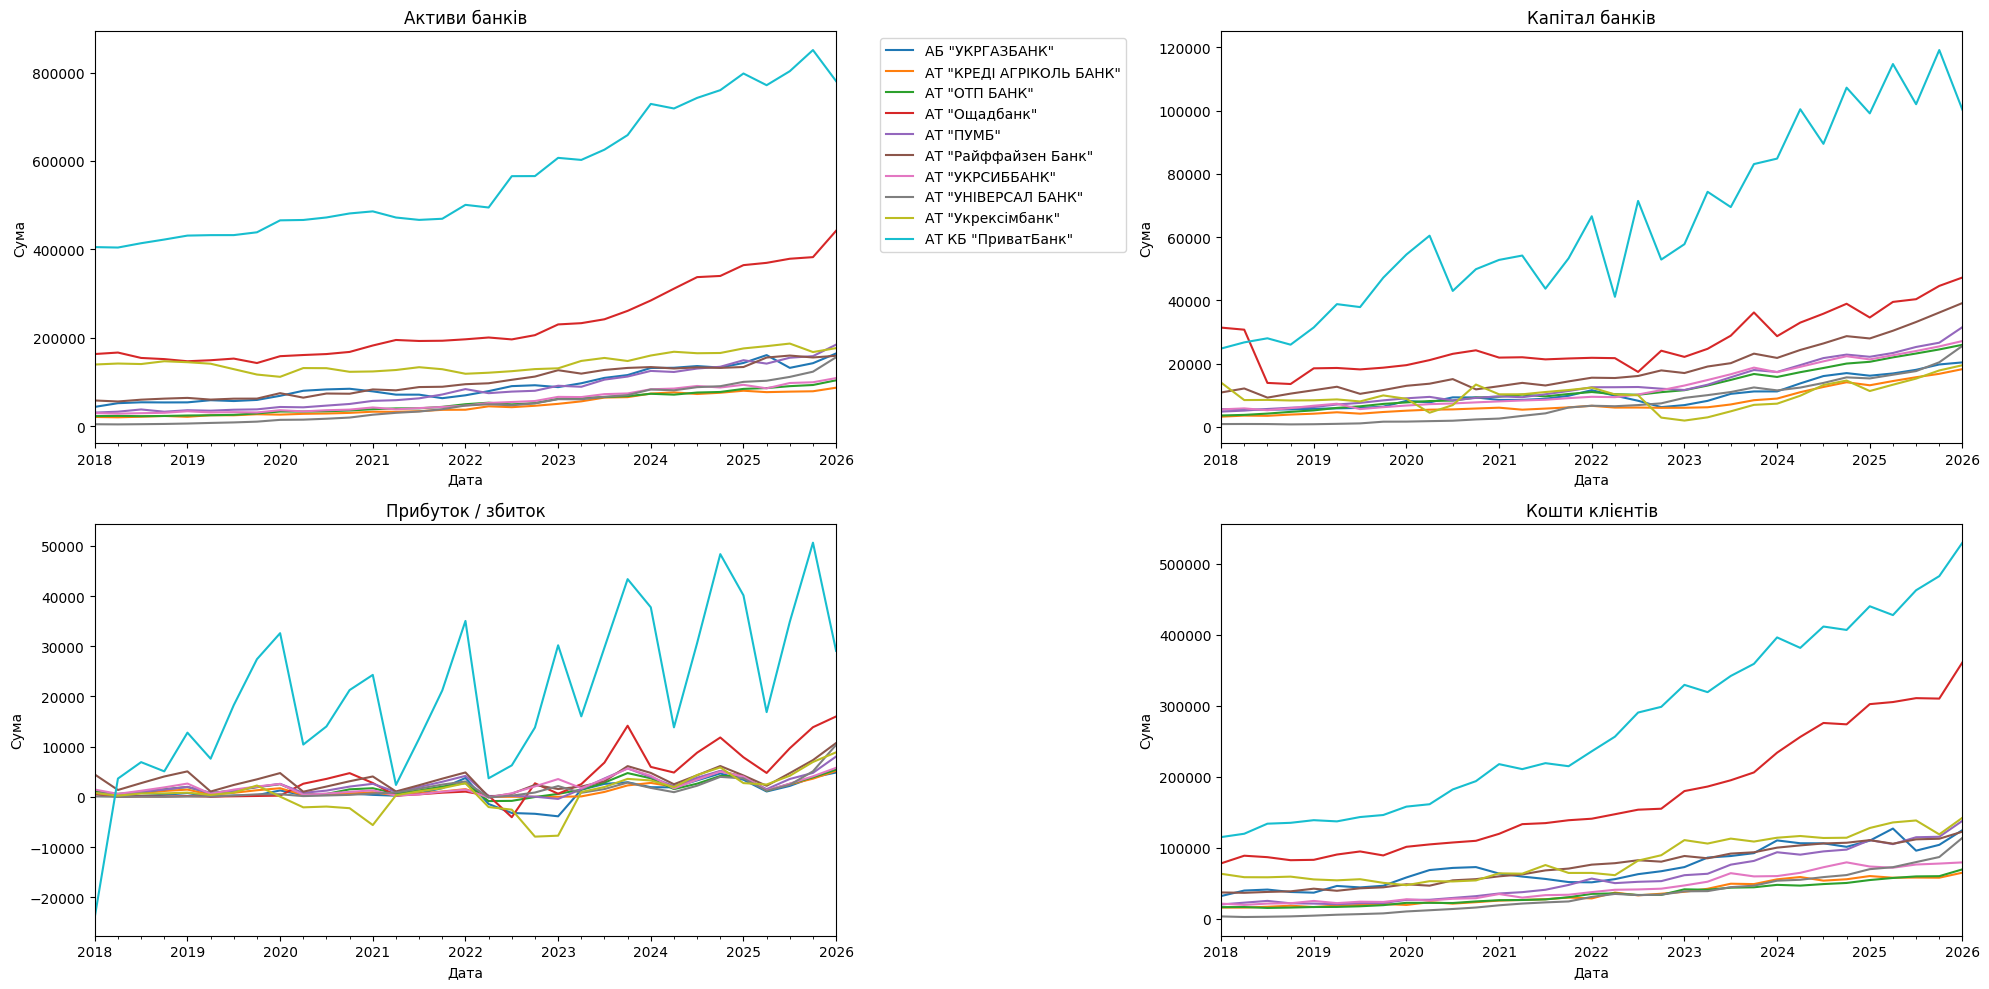

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# 1. Активи
pivot_assets.plot(ax=axes[0, 0])
axes[0, 0].set_title('Активи банків')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Сума')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Капітал
pivot_capital.plot(ax=axes[0, 1])
axes[0, 1].set_title('Капітал банків')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Сума')
axes[0, 1].legend().remove()

# 3. Прибуток
pivot_profit.plot(ax=axes[1, 0])
axes[1, 0].set_title('Прибуток / збиток')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Сума')
axes[1, 0].legend().remove()

# 4. Кошти клієнтів
pivot_liab.plot(ax=axes[1, 1])
axes[1, 1].set_title('Кошти клієнтів')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Сума')
axes[1, 1].legend().remove()


plt.tight_layout()
plt.show()

14. Готуємо зведені таблиці для візуалізації даних для абсолютних показників

In [27]:
pivot_all = df_top.pivot_table(index=['dt', 'mfo', 'SHORTNAME'], columns='id_api', values='value', aggfunc='max').reset_index()
pivot_all['capital_ratio'] = pivot_all['BS1_CapitalTotal'] / pivot_all['BS1_AssetsTotal']
pivot_all['cash_ratio'] = pivot_all['BS1_AssetsCash'] / pivot_all['BS1_LiabCust']
pivot_all['roa'] = pivot_all['BS1_ProfitLossAfterTax'] / pivot_all['BS1_AssetsTotal']
pivot_all['roe'] = pivot_all['BS1_ProfitLossAfterTax'] / pivot_all['BS1_CapitalTotal']

15. За результатами аналізу топ-10 банків виділено три установи з найбільш вираженими відмінностями у показниках, тому саме їх обрано для детального аналізу фінансових коефіцієнтів.

In [28]:
top3 = top_banks.index[:3]
pivot_all_top3 = pivot_all[pivot_all['mfo'].isin(top3)]
pivot_capital_ratio_top3 = pivot_all_top3.pivot_table(index='dt', columns='SHORTNAME', values='capital_ratio')
pivot_cash_ratio_top3 = pivot_all_top3.pivot_table(index='dt', columns='SHORTNAME', values='cash_ratio')
pivot_roa_top3 = pivot_all_top3.pivot_table(index='dt', columns='SHORTNAME', values='roa')
pivot_roe_top3 = pivot_all_top3.pivot_table(index='dt', columns='SHORTNAME', values='roe')

16. Візуалізуємо динаміку фінансових коефіцієнтів для топ-3 банків

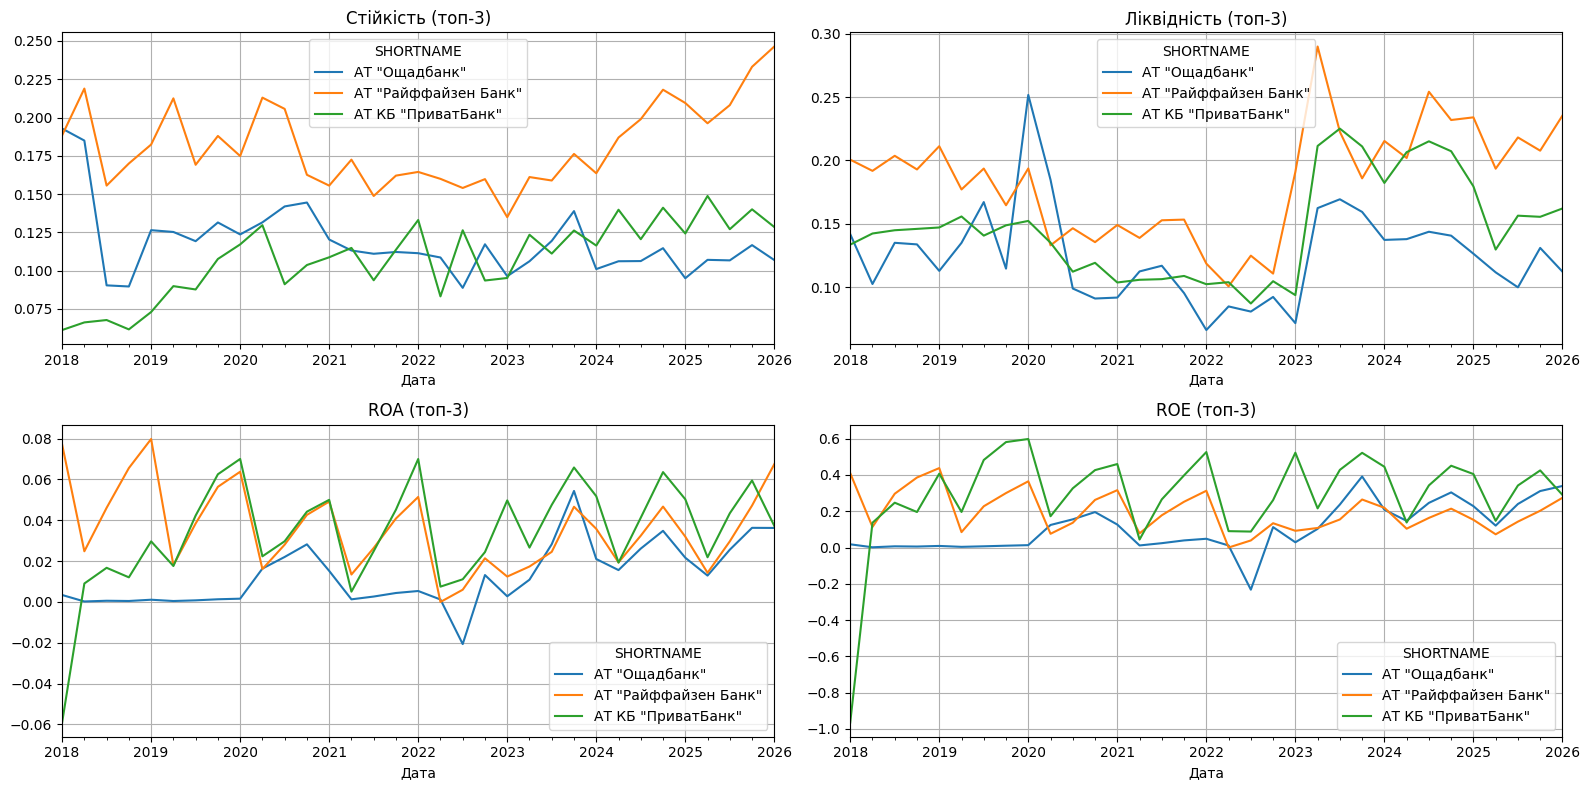

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Стійкість(скільки власного капіталу в кожній гривні)
pivot_capital_ratio_top3.plot(ax=axes[0, 0])
axes[0, 0].set_title('Стійкість (топ-3)')

#Ліквідність (чи вистачить живих грошей покрити зобов’язання)
pivot_cash_ratio_top3.plot(ax=axes[0, 1])
axes[0, 1].set_title('Ліквідність (топ-3)')

#ROA Ефективність (скільки прибутку приносить 1 грн активів)
pivot_roa_top3.plot(ax=axes[1, 0])
axes[1, 0].set_title('ROA (топ-3)')

#ROE — рентабельність капіталу
pivot_roe_top3.plot(ax=axes[1, 1])
axes[1, 1].set_title('ROE (топ-3)')

for ax in axes.flat:
    ax.set_xlabel('Дата')
    ax.grid(True)

plt.tight_layout()
plt.show()

**Висновки:**
У результаті аналізу було визначено топ-10 банків за ключовими фінансовими показниками. До цього списку переважно увійшли великі системні банки, що є очікуваним, оскільки вони мають значні обсяги активів, капіталу та широку клієнтську базу.

За період 2018–2026 років у більшості банків спостерігається зростання активів, власного капіталу та коштів клієнтів. Це свідчить про загальну стабілізацію та розвиток банківського сектору, незважаючи на кризові періоди, зокрема у 2020 році (COVID-19) та після 2022 року (повномасштабна війна).

Прибутковість банків є більш волатильною. У окремих державних банків (зокрема Ощадбанк, Укрексімбанк, Укргазбанк) у деякі періоди спостерігаються збитки.
(припущення) Це може бути пов’язано з особливостями державної політики, зокрема виконанням соціально-економічних функцій або участю у програмах підтримки економіки.

Аналіз коефіцієнтів для топ-3 банків показав, що:

найвищий рівень фінансової стійкості протягом періоду демонструє Райффайзен Банк;
ліквідність у всіх трьох банків знижувалась у 2020–2023 роках, що, ймовірно, пов’язано з кризовими явищами та відтоком коштів клієнтів;
показники рентабельності (ROA, ROE) мають коливання, але загалом залишаються у позитивній зоні.

Окремо варто зазначити, що у ПриватБанку на початку періоду спостерігаються нестабільні значення показників, що може свідчити про наявність фінансових труднощів у попередні роки.

**Практичний висновок:**
Оскільки до топу увійшли системно важливі банки зі стабільними показниками, різниця між ними більше проявляється в умовах для клієнта (ставки, сервіси), ніж у базовій надійності.